# The citation does not say that

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/citation-verifier/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/citation-verifier/demo.ipynb)

A RAG answer cites its sources with [n]. This notebook declares a small corpus and a claim generator, enumerates
every cited claim the generator can emit, and measures - exactly - how often the cited passage does not say
what the claim says, and what five text-only checkers (citation present, context-level lexical, cited-passage
lexical, plus number and negation checks) report instead.

1. The corpus and the generator
2. Calibration - exact enumeration vs raw simulation
3. Five checkers, two model versions
4. The "always cite your sources" instruction, as each checker reports it
5. The threshold that cannot separate a polarity flip from a paraphrase
6. Try your own

## The engine

Extracted from `citation.py` at build time, character for character. A claim is one true fact, one of six edits
(none, polarity, scope, a neighbour's number, a novel number, the other plan's entity), one of four citation
choices (the source, the neighbouring passage, an unrelated one, none), verbatim or paraphrased. SUPPORTED means
the cited passage states the same entity, attribute, value, scope and polarity.

In [1]:
from __future__ import annotations

import functools
import itertools
import re
from collections import Counter
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

SEED = 190


MC_REPS = 200_000


TAU = 0.4


FACTS: List[Tuple[str, str, str, str, str]] = [
    ("billing", "Basic plan", "costs", "$12 per month", "when billed annually"),
    ("billing", "Pro plan", "costs", "$29 per month", "when billed annually"),
    ("billing", "Basic plan", "includes", "2 seats", ""),
    ("billing", "Pro plan", "includes", "5 seats", ""),
    ("refunds", "Basic plan", "offers refunds within", "14 days", "for first-time purchases"),
    ("refunds", "Pro plan", "offers refunds within", "30 days", "for first-time purchases"),
    ("refunds", "Enterprise plan", "offers refunds within", "60 days", "under the master agreement"),
    ("refunds", "Add-on packs", "offers refunds within", "7 days", "if unused"),
    ("support", "Basic plan", "gets a support response within", "48 hours", "on business days"),
    ("support", "Pro plan", "gets a support response within", "8 hours", "on business days"),
    ("support", "Enterprise plan", "gets a support response within", "1 hour", "around the clock"),
    ("support", "Add-on packs", "gets a support response within", "48 hours", "on business days"),
]


NEG = {"costs": "does not cost", "includes": "does not include",
       "offers refunds within": "does not offer refunds within",
       "gets a support response within": "does not get a support response within"}


PARA = {"costs": "is priced at", "includes": "comes with", "offers refunds within": "can be refunded for up to",
        "gets a support response within": "has a support turnaround of"}


PARA_NEG = {"costs": "is not priced at", "includes": "does not come with",
            "offers refunds within": "is not refundable within",
            "gets a support response within": "does not have a support turnaround of"}


PARA_SCOPE = {"when billed annually": "on the annual billing cycle", "for first-time purchases": "on a first purchase",
              "under the master agreement": "per the master agreement", "if unused": "as long as they are unused",
              "on business days": "during business hours", "around the clock": "at any hour", "": ""}


NOVEL = {"costs": "$19 per month", "includes": "3 seats", "offers refunds within": "45 days",
         "gets a support response within": "24 hours"}


OVERGEN = "on every plan"


EDITS = ["none", "polarity", "scope", "value_near", "value_far", "entity"]


CITES = ["source", "neighbour", "unrelated", "none"]


CHECKERS = ["has_citation", "context_lexical", "cited_lexical", "cited_lexical+numbers",
            "cited_lexical+numbers+negation"]


MODELS = {
    "v1 cites when sure": {"edit": [0.80, 0.04, 0.05, 0.04, 0.02, 0.05], "cite": [0.62, 0.08, 0.04, 0.26], "para": 0.35},
    "v2 always cite": {"edit": [0.80, 0.04, 0.05, 0.04, 0.02, 0.05], "cite": [0.52, 0.32, 0.14, 0.02], "para": 0.35},
}


STOP = {"a", "an", "the", "is", "are", "of", "for", "on", "in", "at", "to", "per", "with", "and", "as", "they",
        "be", "up", "any", "every", "does", "do", "not", "no", "can", "cannot", "has", "have", "its", "it", "this",
        "that", "if", "when", "under", "within", "after", "during", "long", "first"}


NEGATORS = {"not", "no", "cannot", "never"}


Fact = Tuple[str, str, str, str, bool]  # entity, attr, value, scope, positive


def render(f: Fact, para: bool = False) -> str:
    entity, attr, value, scope, pos = f
    verb = (PARA[attr] if para else attr) if pos else (PARA_NEG[attr] if para else NEG[attr])
    sc = PARA_SCOPE.get(scope, scope) if para else scope
    return f"{entity} {verb} {value}" + (f" {sc}" if sc else "") + "."


TUPLES: List[Fact] = [(e, a, v, s, True) for _, e, a, v, s in FACTS]


PASSAGES: List[str] = [render(t) for t in TUPLES]


DOC_OF: List[str] = [f[0] for f in FACTS]


TRUE_SET = set(TUPLES)


def sibling(i: int) -> int:
    """The next passage with the same attribute (cyclic) - the neighbour a model confuses it with."""
    attr = FACTS[i][2]
    others = [j for j in range(len(FACTS)) if j != i and FACTS[j][2] == attr]
    return min(others, key=lambda j: (j - i) % len(FACTS))


def edit_claim(i: int, edit: str) -> Fact:
    e, a, v, s, _ = TUPLES[i]
    if edit == "polarity":
        return (e, a, v, s, False)
    if edit == "scope":
        return (e, a, v, OVERGEN, True)
    if edit == "value_near":
        return (e, a, TUPLES[sibling(i)][2], s, True)
    if edit == "value_far":
        return (e, a, NOVEL[a], s, True)
    if edit == "entity":
        return (TUPLES[sibling(i)][0], a, v, s, True)
    return TUPLES[i]


def cited_index(i: int, cite: str) -> Optional[int]:
    if cite == "source":
        return i
    if cite == "neighbour":
        return sibling(i)
    if cite == "unrelated":
        return (i + 4) % len(FACTS)
    return None


def _strip(text: str) -> str:
    """Citation markers are not content: a checker that reads [1] as the number 1 fails every cited claim."""
    return re.sub(r"\[\d+\]", " ", text)


def _content(text: str) -> List[str]:
    toks = re.findall(r"[a-z0-9]+", _strip(text).lower())
    return [t[:-1] if t.endswith("s") and len(t) > 3 else t for t in toks if t not in STOP]


def coverage(claim: str, text: str) -> float:
    c, t = _content(claim), set(_content(text))
    return sum(w in t for w in c) / len(c) if c else 0.0


def numbers(text: str) -> set:
    return set(re.findall(r"\d+(?:\.\d+)?", _strip(text)))


def negations(text: str) -> int:
    return sum(t in NEGATORS for t in re.findall(r"[a-z']+", text.lower()))


def check(claim: str, cited: Optional[str], context: str, tau: float = TAU) -> Dict[str, bool]:
    """Five text-only checkers. `cited` is the passage the claim's [n] names, or None."""
    cov = coverage(claim, cited) if cited is not None else 0.0
    lex = cited is not None and cov >= tau
    num = lex and numbers(claim) <= numbers(cited or "")
    return {"has_citation": cited is not None,
            "context_lexical": coverage(claim, context) >= tau and numbers(claim) <= numbers(context),
            "cited_lexical": lex, "cited_lexical+numbers": num,
            "cited_lexical+numbers+negation": num and negations(claim) == negations(cited or "")}


@functools.lru_cache(maxsize=None)
def build(i: int, edit: str, cite: str, para: bool) -> Dict[str, object]:
    """One claim as the generator would emit it, with its truth labels and checker verdicts (576 distinct)."""
    tup = edit_claim(i, edit)
    j = cited_index(i, cite)
    claim = render(tup, para) + (f" [{j + 1}]" if j is not None else "")
    docs = {DOC_OF[i]} | ({DOC_OF[j]} if j is not None else set())
    context = " ".join(p for p, d in zip(PASSAGES, DOC_OF) if d in docs)
    supported = j is not None and TUPLES[j] == tup
    is_true = tup in TRUE_SET
    klass = ("supported" if supported else "uncited true" if is_true and j is None
             else "misattributed" if is_true else edit)
    return {"claim": claim, "cited": j, "supported": supported, "true": is_true, "klass": klass,
            "edit": edit, "cite": cite, "para": para, "cov": coverage(claim, PASSAGES[j]) if j is not None else 0.0,
            "checks": check(claim, PASSAGES[j] if j is not None else None, context)}


def enumerate_claims(model: Dict) -> List[Dict[str, object]]:
    rows = []
    for i, (ei, e), (ci, c), para in itertools.product(range(len(FACTS)), enumerate(EDITS), enumerate(CITES),
                                                       (False, True)):
        r = dict(build(i, e, c, para))
        r["p"] = model["edit"][ei] * model["cite"][ci] * (model["para"] if para else 1 - model["para"]) / len(FACTS)
        rows.append(r)
    return rows


def summarise(rows: Sequence[Dict[str, object]]) -> Dict[str, object]:
    P = np.array([r["p"] for r in rows])
    sup = np.array([r["supported"] for r in rows])
    out: Dict[str, object] = {"p_supported": float(P[sup].sum()), "p_true": float(sum(r["p"] for r in rows if r["true"])),
                              "p_cited": float(sum(r["p"] for r in rows if r["cited"] is not None)), "scorers": {}}
    for k in CHECKERS:
        ok = np.array([r["checks"][k] for r in rows])
        passed_bad = Counter()
        for r, p, s, o in zip(rows, P, sup, ok):
            if o and not s:
                passed_bad[r["klass"]] += p
        out["scorers"][k] = {"reported": float(P[ok].sum()), "false_pass": float(P[ok & ~sup].sum() / P[~sup].sum()),
                             "false_fail": float(P[~ok & sup].sum() / P[sup].sum()),
                             "bad_among_passes": float(P[ok & ~sup].sum() / P[ok].sum()),
                             "passed_bad_by_class": {c: float(v) for c, v in passed_bad.most_common()}}
    return out


def evaluate() -> Dict[str, Dict[str, object]]:
    return {name: summarise(enumerate_claims(m)) for name, m in MODELS.items()}


def threshold_sweep(model: Dict, taus: Sequence[float]) -> List[Dict[str, float]]:
    """cited_lexical at each tau: how often it fails a supported paraphrase vs passes a polarity flip."""
    rows = enumerate_claims(model)
    out = []
    for tau in taus:
        para_sup = [(r["p"], r["cov"] >= tau) for r in rows if r["supported"] and r["para"]]
        flips = [(r["p"], r["cov"] >= tau) for r in rows if r["edit"] == "polarity" and r["cite"] == "source"]
        out.append({"tau": tau,
                    "fails_supported_paraphrase": 1 - sum(p for p, ok in para_sup if ok) / sum(p for p, _ in para_sup),
                    "passes_polarity_flip": sum(p for p, ok in flips if ok) / sum(p for p, _ in flips)})
    return out


def flip_vs_paraphrase_order(model: Dict) -> Dict[str, float]:
    """Pair-weighted P(a source-cited polarity flip scores above / level with a supported paraphrase)."""
    rows = enumerate_claims(model)
    flips = [(r["p"], r["cov"]) for r in rows if r["edit"] == "polarity" and r["cite"] == "source"]
    paras = [(r["p"], r["cov"]) for r in rows if r["supported"] and r["para"]]
    tot = sum(p for p, _ in flips) * sum(p for p, _ in paras)
    above = sum(pf * pp * (cf > cp + 1e-12) for pf, cf in flips for pp, cp in paras) / tot
    tied = sum(pf * pp * (abs(cf - cp) <= 1e-12) for pf, cf in flips for pp, cp in paras) / tot
    verbatim = [(r["p"], r["cov"]) for r in rows if r["edit"] == "polarity" and r["cite"] == "source" and not r["para"]]
    return {"flip_above": above, "tied": tied, "flip_below": 1 - above - tied,
            "verbatim_flip_coverage_min": min(c for _, c in verbatim)}


def simulate(model: Dict, n: int, seed: int = SEED) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    fi = rng.integers(0, len(FACTS), n)
    ei = rng.choice(len(EDITS), n, p=model["edit"])
    ci = rng.choice(len(CITES), n, p=model["cite"])
    pa = rng.random(n) < model["para"]
    acc = Counter()
    for i, e, c, b in zip(fi, ei, ci, pa):
        r = build(int(i), EDITS[e], CITES[c], bool(b))
        acc["supported"] += r["supported"]
        for k, v in r["checks"].items():
            acc[k] += v
    return {k: acc[k] / n for k in ["supported"] + CHECKERS}


def wilson(p: float, n: int, z: float = 2.576) -> Tuple[float, float]:
    d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h


def calibrate(n: int = MC_REPS, seed: int = SEED) -> List[Dict[str, object]]:
    out = []
    for name, m in MODELS.items():
        ex = summarise(enumerate_claims(m))
        mc = simulate(m, n, seed)
        for k in ["supported"] + CHECKERS:
            e = ex["p_supported"] if k == "supported" else ex["scorers"][k]["reported"]
            lo, hi = wilson(mc[k], n)
            out.append({"model": name, "quantity": k, "exact": e, "mc": mc[k], "inside_99": bool(lo <= e <= hi)})
    return out


def parse_claims(passages_text: str, claims_text: str) -> Tuple[List[str], List[Tuple[str, Optional[int]]]]:
    """Passages one per line (an optional leading [n] is stripped); claims one per line, citing with [n]."""
    passages = [re.sub(r"^\s*\[\d+\]\s*", "", ln).strip() for ln in passages_text.strip().splitlines() if ln.strip()]
    if not passages:
        raise ValueError("paste at least one passage")
    claims = []
    for ln in [x.strip() for x in claims_text.strip().splitlines() if x.strip()]:
        m = re.search(r"\[(\d+)\]", ln)
        j = int(m.group(1)) - 1 if m else None
        if j is not None and not 0 <= j < len(passages):
            raise ValueError(f"citation [{j + 1}] names a passage that is not there: {ln[:60]!r}")
        claims.append((ln, j))
    if not claims:
        raise ValueError("paste at least one claim")
    return passages, claims


def audit(passages: List[str], claims: List[Tuple[str, Optional[int]]], tau: float = TAU) -> List[Dict[str, object]]:
    """Checker verdicts on the user's own claims, with the disagreements that point at a wrong citation."""
    context = " ".join(passages)
    out = []
    for claim, j in claims:
        cited = passages[j] if j is not None else None
        ch = check(claim, cited, context, tau)
        notes = []
        if j is None:
            notes.append("no citation")
        else:
            if ch["context_lexical"] and not ch["cited_lexical"]:
                notes.append("in the context, not in the cited passage")
            if ch["cited_lexical"] and not ch["cited_lexical+numbers"]:
                notes.append("a number the cited passage does not hold: " + ", ".join(sorted(numbers(claim) - numbers(cited or ""))))
            if ch["cited_lexical+numbers"] and not ch["cited_lexical+numbers+negation"]:
                notes.append("polarity differs from the cited passage")
            if ch["cited_lexical+numbers+negation"]:
                notes.append("lexically consistent - entity and scope are NOT checked by any of these")
        out.append({"claim": claim, "cited": j, "coverage": coverage(claim, cited) if cited else 0.0, "checks": ch,
                    "notes": notes})
    return out

print('engine loaded')

engine loaded


**Resolution of the instrument.** Every checker number here is exact and matches `evidence.txt` to the digit.
Only the calibration's raw simulation runs at 20,000 replicates instead of the study's 200,000.

## 1. The corpus and the generator

In [2]:
for i, p in enumerate(PASSAGES):
    print(f"[{i + 1:>2}] {p}")
r = build(5, "polarity", "source", False)
print()
print(r["claim"], "->", "supported" if r["supported"] else "NOT supported", "| coverage", round(r["cov"], 2))
print("passes:", [k for k, v in r["checks"].items() if v])

[ 1] Basic plan costs $12 per month when billed annually.
[ 2] Pro plan costs $29 per month when billed annually.
[ 3] Basic plan includes 2 seats.
[ 4] Pro plan includes 5 seats.
[ 5] Basic plan offers refunds within 14 days for first-time purchases.
[ 6] Pro plan offers refunds within 30 days for first-time purchases.
[ 7] Enterprise plan offers refunds within 60 days under the master agreement.
[ 8] Add-on packs offers refunds within 7 days if unused.
[ 9] Basic plan gets a support response within 48 hours on business days.
[10] Pro plan gets a support response within 8 hours on business days.
[11] Enterprise plan gets a support response within 1 hour around the clock.
[12] Add-on packs gets a support response within 48 hours on business days.

Pro plan does not offer refunds within 30 days for first-time purchases. [6] -> NOT supported | coverage 1.0
passes: ['has_citation', 'context_lexical', 'cited_lexical', 'cited_lexical+numbers']


The last lines are the whole problem in one row: a polarity flip has coverage 1.00 against its source, because
the stopword list drops "not". Only the negation count sees it.

## 2. Calibration

In [3]:
cal = calibrate(20000)
print(f"inside their 99% interval: {sum(r['inside_99'] for r in cal)} of {len(cal)}")

inside their 99% interval: 12 of 12


## 3. Five checkers, two model versions

In [4]:
ev = evaluate()
for name, s in ev.items():
    print(f"{name}: supported by its citation {s['p_supported']:.1%}, claim true {s['p_true']:.1%}, "
          f"carries a citation {s['p_cited']:.1%}")
    for k, v in s["scorers"].items():
        print(f"   {k:<32} reports {v['reported']:6.1%}  passes bad {v['false_pass']:6.1%}  "
              f"fails good {v['false_fail']:6.1%}  bad among passes {v['bad_among_passes']:6.1%}")

v1 cites when sure: supported by its citation 49.8%, claim true 80.8%, carries a citation 74.0%
   has_citation                     reports  74.0%  passes bad  48.2%  fails good   0.0%  bad among passes  32.6%
   context_lexical                  reports  98.0%  passes bad  96.0%  fails good   0.0%  bad among passes  49.1%
   cited_lexical                    reports  68.8%  passes bad  37.7%  fails good   0.0%  bad among passes  27.5%
   cited_lexical+numbers            reports  59.2%  passes bad  18.7%  fails good   0.0%  bad among passes  15.8%
   cited_lexical+numbers+negation   reports  56.7%  passes bad  13.7%  fails good   0.0%  bad among passes  12.1%
v2 always cite: supported by its citation 41.9%, claim true 80.7%, carries a citation 98.0%
   has_citation                     reports  98.0%  passes bad  96.6%  fails good   0.0%  bad among passes  57.2%
   context_lexical                  reports  98.0%  passes bad  96.6%  fails good   0.0%  bad among passes  57.2%
   cited_lexic

Half of v1's claims are supported by the passage they cite, though 81% of them are true: the rest are true and
uncited, or true and pointing at the wrong passage. The context-level check (is the vocabulary anywhere in the
retrieved context) passes 98% - every edit here reuses context vocabulary, including the neighbour's number.
The sharpest lexical rule still passes a widened scope and the other plan's fact, because those share every
content word with the passage.

## 4. The instruction change

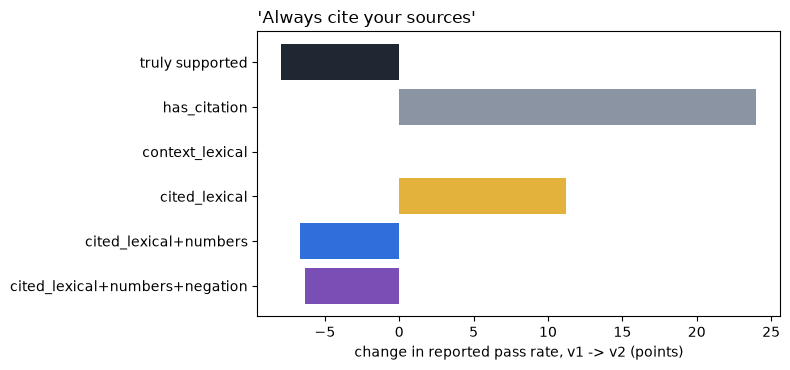

truly supported                    -7.9 pts
has_citation                      +24.0 pts
context_lexical                    +0.0 pts
cited_lexical                     +11.2 pts
cited_lexical+numbers              -6.7 pts
cited_lexical+numbers+negation     -6.4 pts


In [5]:
v1, v2 = ev["v1 cites when sure"], ev["v2 always cite"]
names = ["truly supported"] + list(CHECKERS)
d = [v2["p_supported"] - v1["p_supported"]] + [v2["scorers"][k]["reported"] - v1["scorers"][k]["reported"] for k in CHECKERS]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(names[::-1], [x * 100 for x in d][::-1], color=["#7a4fb5", "#2f6fdb", "#e3b23c", "#8a6d3b", "#8a94a3", "#1f2733"])
ax.set_xlabel("change in reported pass rate, v1 -> v2 (points)")
ax.set_title("'Always cite your sources'", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()
for n, x in zip(names, d):
    print(f"{n:<32} {x * 100:+6.1f} pts")

Citations went from 74% to 98% of claims and support fell 8 points: the new citations point at the neighbouring
passage (same attribute, other plan). Citation coverage reports +24. The cited-passage lexical check reports
+11, because the neighbour shares most of the claim's words. Only the rules that check numbers see the sign.

## 5. The threshold

In [6]:
m = MODELS["v1 cites when sure"]
for r in threshold_sweep(m, [0.3, 0.5, 0.6, 0.8, 0.9, 1.0]):
    print(f"tau {r['tau']:.2f}  fails a supported paraphrase {r['fails_supported_paraphrase']:6.1%}   "
          f"passes a polarity flip {r['passes_polarity_flip']:6.1%}")
o = flip_vs_paraphrase_order(m)
print(f"flip scores above the paraphrase in {o['flip_above']:.1%} of pairs, level in {o['tied']:.1%}")

tau 0.30  fails a supported paraphrase   0.0%   passes a polarity flip 100.0%
tau 0.50  fails a supported paraphrase   0.0%   passes a polarity flip 100.0%
tau 0.60  fails a supported paraphrase  16.6%   passes a polarity flip  94.2%
tau 0.80  fails a supported paraphrase  16.6%   passes a polarity flip  94.2%
tau 0.90  fails a supported paraphrase 100.0%   passes a polarity flip  65.0%
tau 1.00  fails a supported paraphrase 100.0%   passes a polarity flip  65.0%
flip scores above the paraphrase in 78.8% of pairs, level in 7.3%


Raising the threshold fails honest paraphrases before it fails flips. The flip is a closer lexical match than the
paraphrase in 79% of pairs, so no threshold on this score separates them.

## Summary

| claim | what the numbers say |
|---|---|
| "every sentence has a citation now" | coverage +24 points, support -8: the new citations name the neighbour |
| "the cited passage shares the words" | +11 points for a -8 change; passes 66% of v2's unsupported claims |
| "check the numbers too" | tracks the sign; still passes a widened scope and the other plan's fact |
| "raise the lexical threshold" | fails paraphrases first - a flip is lexically closer than a paraphrase |
| "it is in the context" | a different question: 98% of claims, including the misattributed ones |

## 6. Try your own

In [7]:
# passages, claims = parse_claims(
#     "[1] Pro plan includes 5 seats.\n[2] Basic plan includes 2 seats.",
#     "Pro plan comes with 5 seats. [1]\nPro plan includes 2 seats. [1]\nBasic plan does not include 2 seats. [2]")
# for r in audit(passages, claims):
#     print(r["claim"], [k for k, v in r["checks"].items() if v], r["notes"])
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](llmops-genai-platform/citation-verifier)

Streamlit version, where you paste your own passages and claims:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`hallucination-checker`](../hallucination-checker) asks whether a claim is anywhere in the
retrieved context - the `context_lexical` baseline here; [`agent-trajectory-eval`](../agent-trajectory-eval) is the
previous day's audit of a scorer that sat still while quality moved.